In [1]:
%matplotlib inline
import numpy as np
import torch

torch.set_printoptions(edgeitems=2, linewidth=75)

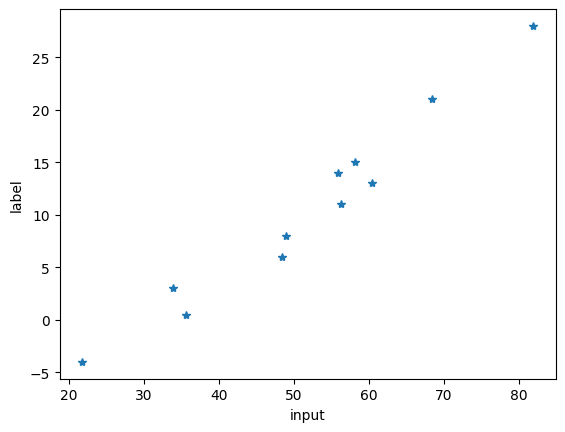

In [2]:
t_u = [35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4]  # 输入
t_c = [0.5, 14.0, 15.0, 28.0, 11.0, 8.0, 3.0, -4.0, 6.0, 13.0, 21.0]  # 标签值

t_c = torch.tensor(t_c)
t_u = torch.tensor(t_u)

from matplotlib import pyplot as plt

plt.plot(t_u.numpy(), t_c.numpy(), "*")
plt.xlabel("input")
plt.ylabel("label")
plt.show()

In [3]:
# 在我们的模型中, 参数是 PyTorch 标量(也称为 0 维张量), 通过乘积运算和广播来生成返回的张量
def model(t_u, w, b):
    return w * t_u + b


w = torch.ones(())
b = torch.zeros(())

print("w:", w)
print("w:", w.shape)
print("b:", b)
print("b:", b.shape)

t_p = model(t_u, w, b)
print("t_p:", t_p)
print("t_p:", t_p.shape)

w: tensor(1.)
w: torch.Size([])
b: tensor(0.)
b: torch.Size([])
t_p: tensor([35.7000, 55.9000, 58.2000, 81.9000, 56.3000, 48.9000, 33.9000,
        21.8000, 48.4000, 60.4000, 68.4000])
t_p: torch.Size([11])


In [4]:
def loss_fn(t_p, t_c):
    squared_diffs = (t_p - t_c) ** 2
    return squared_diffs.mean()


loss = loss_fn(t_p, t_c)
print("loss:", loss)
print("loss:", loss.shape)

loss: tensor(1763.8848)
loss: torch.Size([])


### 说明 PyTorch 广播机制

In [5]:
x = torch.ones(())
y = torch.ones(3, 1)
z = torch.ones(1, 3)
a = torch.ones(2, 1, 1)
print(f"shapes: x: {x.shape}, y: {y.shape}")
print(f"        z: {z.shape}, a: {a.shape}")
print("x * y:", (x * y).shape)
print("y * z:", (y * z).shape)
print("y * z * a:", (y * z * a).shape)

shapes: x: torch.Size([]), y: torch.Size([3, 1])
        z: torch.Size([1, 3]), a: torch.Size([2, 1, 1])
x * y: torch.Size([3, 1])
y * z: torch.Size([3, 3])
y * z * a: torch.Size([2, 3, 3])


In [6]:
# 减小损失
delta = 0.1

loss_rate_of_change_w = (
    loss_fn(model(t_u, w + delta, b), t_c) - loss_fn(model(t_u, w - delta, b), t_c)
) / (2.0 * delta)
loss_rate_of_change_w

tensor(4517.2974)

In [7]:
# 学习率
learning_rate = 1e-2

w = w - learning_rate * loss_rate_of_change_w
w

tensor(-44.1730)

In [8]:
loss_rate_of_change_b = (
    loss_fn(model(t_u, w, b + delta), t_c) - loss_fn(model(t_u, w, b - delta), t_c)
) / (2.0 * delta)

b = b - learning_rate * loss_rate_of_change_b
b

tensor(46.)

#### 将导数应用到损失函数中

In [9]:
def dloss_fn(t_p, t_c):
    dsq_diffs = 2 * (t_p - t_c) / t_p.size(0)
    return dsq_diffs


print("t_p:", t_p)
print("t_p:", t_p.shape)
print("t_c:", t_c)
print("t_c:", t_c.shape)
dloss_fn(t_p, t_c)

t_p: tensor([35.7000, 55.9000, 58.2000, 81.9000, 56.3000, 48.9000, 33.9000,
        21.8000, 48.4000, 60.4000, 68.4000])
t_p: torch.Size([11])
t_c: tensor([ 0.5000, 14.0000, 15.0000, 28.0000, 11.0000,  8.0000,  3.0000,
        -4.0000,  6.0000, 13.0000, 21.0000])
t_c: torch.Size([11])


tensor([6.4000, 7.6182, 7.8545, 9.8000, 8.2364, 7.4364, 5.6182, 4.6909,
        7.7091, 8.6182, 8.6182])

#### 将导数应用到模型中

In [10]:
def dmodel_dw(t_u, w, b):
    return t_u


print("t_u:", t_u)
print("t_u:", t_u.shape)
print("w:", w)
print("w:", w.shape)
print("b:", b)
print("b:", b.shape)
dmodel_dw(t_u, w, b)

t_u: tensor([35.7000, 55.9000, 58.2000, 81.9000, 56.3000, 48.9000, 33.9000,
        21.8000, 48.4000, 60.4000, 68.4000])
t_u: torch.Size([11])
w: tensor(-44.1730)
w: torch.Size([])
b: tensor(46.)
b: torch.Size([])


tensor([35.7000, 55.9000, 58.2000, 81.9000, 56.3000, 48.9000, 33.9000,
        21.8000, 48.4000, 60.4000, 68.4000])

In [11]:
def dmodel_db(t_u, w, b):
    return 1.0


print("t_u:", t_u)
print("t_u:", t_u.shape)
print("w:", w)
print("w:", w.shape)
print("b:", b)
print("b:", b.shape)
dmodel_db(t_u, w, b)

t_u: tensor([35.7000, 55.9000, 58.2000, 81.9000, 56.3000, 48.9000, 33.9000,
        21.8000, 48.4000, 60.4000, 68.4000])
t_u: torch.Size([11])
w: tensor(-44.1730)
w: torch.Size([])
b: tensor(46.)
b: torch.Size([])


1.0

In [12]:
# 定义梯度函数
def grad_fn(t_u, t_c, t_p, w, b):
    dloss_dtp = dloss_fn(t_p, t_c)  # dloss_dtp: torch.Size([11])
    dloss_dw = dloss_dtp * dmodel_dw(t_u, w, b)  # dloss_dw: torch.Size([11])
    dloss_db = dloss_dtp * dmodel_db(t_u, w, b)  # dloss_db: torch.Size([11])
    return torch.stack([dloss_dw.sum(), dloss_db.sum()])  # 这里有 sum 操作


grad_fn(t_u, t_c, t_p, w, b)

tensor([4517.2964,   82.6000])

In [13]:
# n_epochs 迭代周期(epoch)
def training_loop(n_epochs, learning_rate, params, t_u, t_c):
    for epoch in range(1, n_epochs + 1):
        w, b = params

        t_p = model(t_u, w, b)  # 正向传播
        loss = loss_fn(t_p, t_c)  # 计算损失
        grad = grad_fn(t_u, t_c, t_p, w, b)  # 反向传播

        params = params - learning_rate * grad  # 更新参数

        print("Epoch %d, Loss %f" % (epoch, float(loss)))  # 这个日志可能非常冗长

    return params


training_loop(
    n_epochs=100, learning_rate=1e-2, params=torch.tensor([1.0, 0.0]), t_u=t_u, t_c=t_c
)

Epoch 1, Loss 1763.884766
Epoch 2, Loss 5802484.500000
Epoch 3, Loss 19408029696.000000
Epoch 4, Loss 64915905708032.000000
Epoch 5, Loss 217130525461053440.000000
Epoch 6, Loss 726257583152928129024.000000
Epoch 7, Loss 2429183416467662896627712.000000
Epoch 8, Loss 8125122549611731432050262016.000000
Epoch 9, Loss 27176882120842590626938030653440.000000
Epoch 10, Loss 90901105189019073810297959556841472.000000
Epoch 11, Loss inf
Epoch 12, Loss inf
Epoch 13, Loss inf
Epoch 14, Loss inf
Epoch 15, Loss inf
Epoch 16, Loss inf
Epoch 17, Loss inf
Epoch 18, Loss inf
Epoch 19, Loss inf
Epoch 20, Loss inf
Epoch 21, Loss inf
Epoch 22, Loss inf
Epoch 23, Loss nan
Epoch 24, Loss nan
Epoch 25, Loss nan
Epoch 26, Loss nan
Epoch 27, Loss nan
Epoch 28, Loss nan
Epoch 29, Loss nan
Epoch 30, Loss nan
Epoch 31, Loss nan
Epoch 32, Loss nan
Epoch 33, Loss nan
Epoch 34, Loss nan
Epoch 35, Loss nan
Epoch 36, Loss nan
Epoch 37, Loss nan
Epoch 38, Loss nan
Epoch 39, Loss nan
Epoch 40, Loss nan
Epoch 41, Loss

tensor([nan, nan])

In [14]:
def training_loop(n_epochs, learning_rate, params, t_u, t_c, print_params=True):
    for epoch in range(1, n_epochs + 1):
        w, b = params

        t_p = model(t_u, w, b)  # 正向传播
        loss = loss_fn(t_p, t_c)  # 计算损失
        grad = grad_fn(t_u, t_c, t_p, w, b)  # 反向传播

        params = params - learning_rate * grad  # 更新参数

        if epoch in {1, 2, 3, 10, 11, 99, 100, 4000, 5000}:
            print("Epoch %d, Loss %f" % (epoch, float(loss)))
            if print_params:
                print("    Params:", params)
                print("    Grad:  ", grad)
        if epoch in {4, 12, 101}:
            print("...")

        if not torch.isfinite(loss).all():
            break

    return params

In [15]:
training_loop(
    n_epochs=100, learning_rate=1e-2, params=torch.tensor([1.0, 0.0]), t_u=t_u, t_c=t_c
)

Epoch 1, Loss 1763.884766
    Params: tensor([-44.1730,  -0.8260])
    Grad:   tensor([4517.2964,   82.6000])
Epoch 2, Loss 5802484.500000
    Params: tensor([2568.4011,   45.1637])
    Grad:   tensor([-261257.4062,   -4598.9702])
Epoch 3, Loss 19408029696.000000
    Params: tensor([-148527.7344,   -2616.3931])
    Grad:   tensor([15109614.0000,   266155.6875])
...
Epoch 10, Loss 90901105189019073810297959556841472.000000
    Params: tensor([3.2144e+17, 5.6621e+15])
    Grad:   tensor([-3.2700e+19, -5.7600e+17])
Epoch 11, Loss inf
    Params: tensor([-1.8590e+19, -3.2746e+17])
    Grad:   tensor([1.8912e+21, 3.3313e+19])


tensor([-1.8590e+19, -3.2746e+17])

In [16]:
# 降低学习率
training_loop(
    n_epochs=100, learning_rate=1e-4, params=torch.tensor([1.0, 0.0]), t_u=t_u, t_c=t_c
)

Epoch 1, Loss 1763.884766
    Params: tensor([ 0.5483, -0.0083])
    Grad:   tensor([4517.2964,   82.6000])
Epoch 2, Loss 323.090515
    Params: tensor([ 0.3623, -0.0118])
    Grad:   tensor([1859.5493,   35.7843])
Epoch 3, Loss 78.929634
    Params: tensor([ 0.2858, -0.0135])
    Grad:   tensor([765.4666,  16.5122])
...
Epoch 10, Loss 29.105247
    Params: tensor([ 0.2324, -0.0166])
    Grad:   tensor([1.4803, 3.0544])
Epoch 11, Loss 29.104168
    Params: tensor([ 0.2323, -0.0169])
    Grad:   tensor([0.5781, 3.0384])
...
Epoch 99, Loss 29.023582
    Params: tensor([ 0.2327, -0.0435])
    Grad:   tensor([-0.0533,  3.0226])
Epoch 100, Loss 29.022667
    Params: tensor([ 0.2327, -0.0438])
    Grad:   tensor([-0.0532,  3.0226])


tensor([ 0.2327, -0.0438])

In [17]:
# 归一化输入
t_un = 0.1 * t_u
training_loop(
    n_epochs=100,
    learning_rate=1e-2,
    params=torch.tensor([1.0, 0.0]),
    t_u=t_un,
    t_c=t_c,
)

Epoch 1, Loss 80.364342
    Params: tensor([1.7761, 0.1064])
    Grad:   tensor([-77.6140, -10.6400])
Epoch 2, Loss 37.574913
    Params: tensor([2.0848, 0.1303])
    Grad:   tensor([-30.8623,  -2.3864])
Epoch 3, Loss 30.871077
    Params: tensor([2.2094, 0.1217])
    Grad:   tensor([-12.4631,   0.8587])
...
Epoch 10, Loss 29.030489
    Params: tensor([ 2.3232, -0.0710])
    Grad:   tensor([-0.5355,  2.9295])
Epoch 11, Loss 28.941877
    Params: tensor([ 2.3284, -0.1003])
    Grad:   tensor([-0.5240,  2.9264])
...
Epoch 99, Loss 22.214186
    Params: tensor([ 2.7508, -2.4910])
    Grad:   tensor([-0.4453,  2.5208])
Epoch 100, Loss 22.148710
    Params: tensor([ 2.7553, -2.5162])
    Grad:   tensor([-0.4446,  2.5165])


tensor([ 2.7553, -2.5162])

In [18]:
# 增加迭代周期(epoch)
params = training_loop(
    n_epochs=5000,
    learning_rate=1e-2,
    params=torch.tensor([1.0, 0.0]),
    t_u=t_un,
    t_c=t_c,
    print_params=False,
)

params

Epoch 1, Loss 80.364342
Epoch 2, Loss 37.574913
Epoch 3, Loss 30.871077
...
Epoch 10, Loss 29.030489
Epoch 11, Loss 28.941877
...
Epoch 99, Loss 22.214186
Epoch 100, Loss 22.148710
...
Epoch 4000, Loss 2.927680
Epoch 5000, Loss 2.927648


tensor([  5.3671, -17.3012])

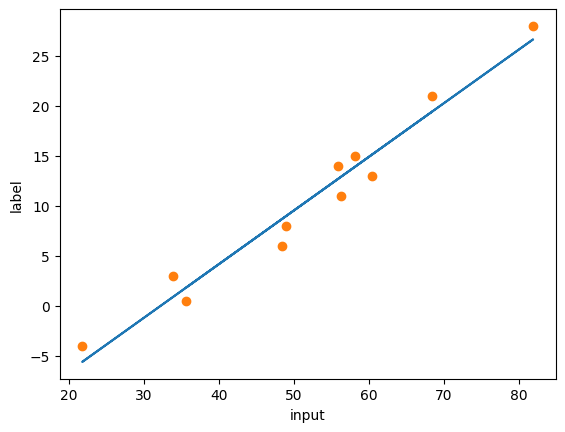

In [19]:
%matplotlib inline
from matplotlib import pyplot as plt

t_p = model(t_un, *params)

plt.plot(t_u.numpy(), t_p.detach().numpy())
plt.plot(t_u.numpy(), t_c.numpy(), "o")
plt.xlabel("input")
plt.ylabel("label")

plt.show()